# Task
Analyze the 'Tips' dataset to understand the bivariate normal distribution of two selected numerical features, including implementing a custom PDF function, calculating PDF values, generating contour and 3D plots, and summarizing the findings. Use the data from "tip.csv"


## Load Tips Dataset

### Subtask:
Load the 'Tips' dataset using a suitable library (e.g., pandas or seaborn's built-in datasets) into a DataFrame.


In [1]:
import pandas as pd

df = pd.read_csv('tip.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Prepare Data for Bivariate Normal Distribution

### Subtask:
Select two relevant numerical features from the Tips dataset to use for the bivariate normal distribution calculation. Clean any missing values if necessary.


**Reasoning**:
The subtask requires selecting 'total_bill' and 'tip' as the numerical features and checking for missing values. This step will display descriptive statistics for these columns to understand their distribution and identify any initial data quality issues like missing values.



In [2]:
print("Descriptive statistics for 'total_bill' and 'tip':")
print(df[['total_bill', 'tip']].describe())

print("\nChecking for missing values in 'total_bill' and 'tip':")
print(df[['total_bill', 'tip']].isnull().sum())

Descriptive statistics for 'total_bill' and 'tip':
       total_bill         tip
count  244.000000  244.000000
mean    19.785943    2.998279
std      8.902412    1.383638
min      3.070000    1.000000
25%     13.347500    2.000000
50%     17.795000    2.900000
75%     24.127500    3.562500
max     50.810000   10.000000

Checking for missing values in 'total_bill' and 'tip':
total_bill    0
tip           0
dtype: int64


## Implement Bivariate Normal PDF

### Subtask:
Write a Python function from scratch to calculate the probability density function (PDF) for a bivariate normal distribution. This function should take two data points (x, y), the means (mu_x, mu_y), and the covariance matrix (Sigma) as input, and return the PDF value. Do not use any pre-built statistical libraries for this specific calculation.


In [3]:
import numpy as np
import math

def bivariate_normal_pdf(x, y, mu_x, mu_y, Sigma):
    """
    Calculates the probability density function (PDF) for a bivariate normal distribution.

    Args:
        x (float): The x-coordinate of the point.
        y (float): The y-coordinate of the point.
        mu_x (float): The mean of the x-coordinate.
        mu_y (float): The mean of the y-coordinate.
        Sigma (np.ndarray): The 2x2 covariance matrix.

    Returns:
        float: The PDF value at the given point (x, y).
    """
    # Create a mean vector mu
    mu = np.array([[mu_x], [mu_y]])

    # Create the data point vector X
    X = np.array([[x], [y]])

    # Calculate the difference vector x_minus_mu
    x_minus_mu = X - mu

    # Calculate the determinant of the covariance matrix Sigma
    determinant_Sigma = np.linalg.det(Sigma)

    # Calculate the inverse of the covariance matrix Sigma
    inverse_Sigma = np.linalg.inv(Sigma)

    # Calculate the exponent term
    # The result of x_minus_mu.T @ inverse_Sigma @ x_minus_mu is a 1x1 array. We need to extract its scalar value.
    exponent_term_matrix = x_minus_mu.T @ inverse_Sigma @ x_minus_mu
    exponent = -0.5 * exponent_term_matrix.item() # Use .item() to get the scalar value

    # Calculate the PDF value
    pdf_value = (1 / (2 * math.pi * math.sqrt(determinant_Sigma))) * math.exp(exponent)

    return pdf_value

print("bivariate_normal_pdf function defined successfully.")

bivariate_normal_pdf function defined successfully.


## Compute PDF Values

### Subtask:
Calculate the mean and covariance matrix for the selected features from the Tips dataset. Then, iterate through the dataset and compute the bivariate normal PDF value for each data point using the custom implemented function.


In [4]:
selected_features = df[['total_bill', 'tip']]

mu_x = selected_features['total_bill'].mean()
mu_y = selected_features['tip'].mean()

Sigma = selected_features.cov().values

sigma_x = np.sqrt(Sigma[0, 0])
sigma_y = np.sqrt(Sigma[1, 1])
rho = Sigma[0, 1] / (sigma_x * sigma_y)

print(f"Mean of total_bill (mu_x): {mu_x:.2f}")
print(f"Mean of tip (mu_y): {mu_y:.2f}")
print("Covariance Matrix (Sigma):")
print(Sigma)
print(f"Correlation (rho): {rho:.4f}")

pdf_values = []
for index, row in df.iterrows():
    x = row['total_bill']
    y = row['tip']
    pdf_val = bivariate_normal_pdf(x, y, mu_x, mu_y, Sigma)
    pdf_values.append(pdf_val)

print(f"\nCalculated {len(pdf_values)} PDF values. First 5 values:")
print(pdf_values[:5])

Mean of total_bill (mu_x): 19.79
Mean of tip (mu_y): 3.00
Covariance Matrix (Sigma):
[[79.25293861  8.32350163]
 [ 8.32350163  1.91445464]]
Correlation (rho): 0.6757

Calculated 244 PDF values. First 5 values:
[0.00419627546049814, 0.00942416502225316, 0.016239180048196446, 0.015856786173780085, 0.015069687717987149]


## Generate Contour Plot

### Subtask:
Use Matplotlib to create a contour plot visualizing the bivariate normal PDF. This will involve creating a grid of x and y values, calculating the PDF for each point on the grid, and then plotting the contours. 


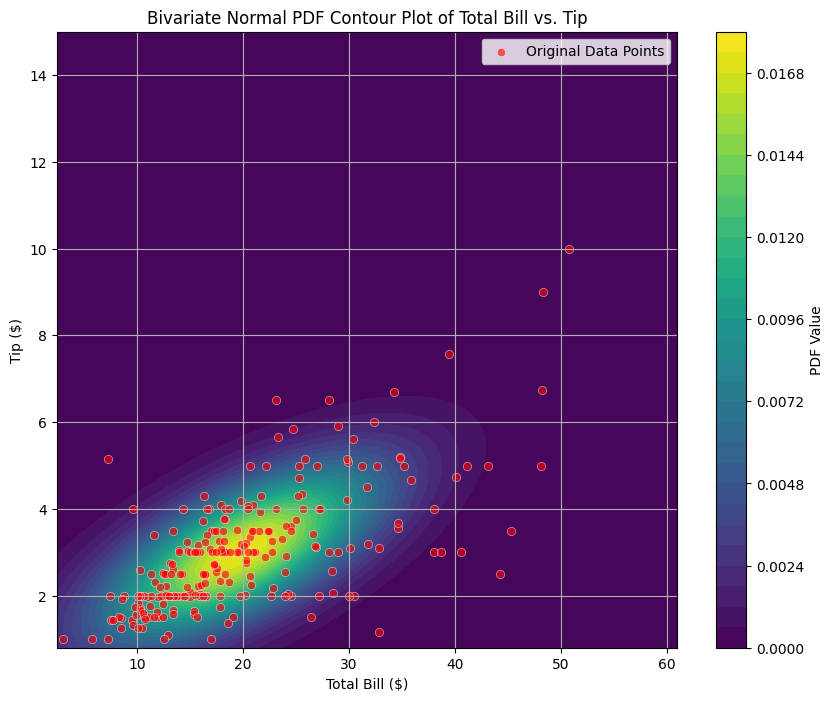

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define range for 'total_bill' (x-axis) and 'tip' (y-axis)
min_total_bill, max_total_bill = selected_features['total_bill'].min(), selected_features['total_bill'].max()
min_tip, max_tip = selected_features['tip'].min(), selected_features['tip'].max()

x_range = np.linspace(min_total_bill * 0.8, max_total_bill * 1.2, 100) # Extend range slightly for better visualization
y_range = np.linspace(min_tip * 0.8, max_tip * 1.5, 100) # Extend range slightly for better visualization

# Create a meshgrid
X, Y = np.meshgrid(x_range, y_range)

# Initialize an empty array Z to store PDF values
Z = np.zeros_like(X)

# Calculate PDF for each grid point
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = bivariate_normal_pdf(X[i, j], Y[i, j], mu_x, mu_y, Sigma)

# Create the contour plot
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(contour, label='PDF Value')

# Add a scatter plot of the original data points
sns.scatterplot(x='total_bill', y='tip', data=df, color='red', alpha=0.6, label='Original Data Points')

# Add labels and title
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Bivariate Normal PDF Contour Plot of Total Bill vs. Tip')
plt.legend()
plt.grid(True)
plt.show()

## Create 3D Plot

### Subtask:
Create a 3D surface plot to visualize the bivariate normal PDF. This plot should represent the x and y axes as 'total_bill' and 'tip', and the z-axis as the PDF value. 

**Reasoning**:
To visualize the bivariate normal PDF in three dimensions, I will use the previously calculated meshgrid `X`, `Y`, and `Z` (PDF values) and plot them using Matplotlib's 3D plotting. This will provide a surface representation of 

1.   List item
2.   List item

the probability density.



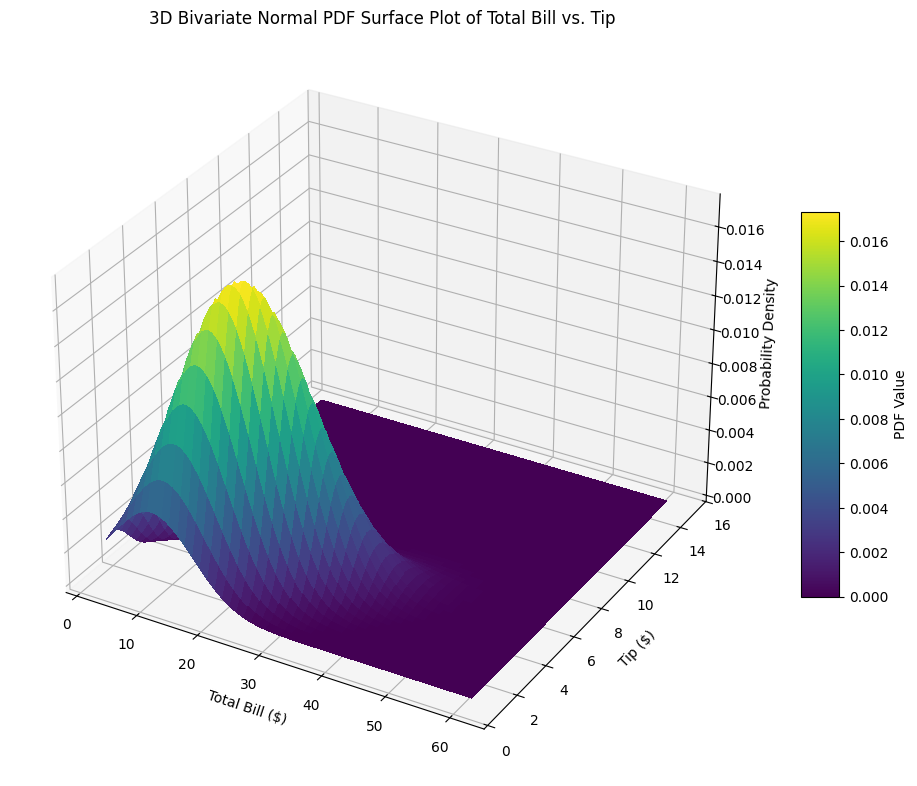

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create the 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)

# Add a color bar
fig.colorbar(surface, shrink=0.5, aspect=10, label='PDF Value')

# Set labels and title
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_zlabel('Probability Density')
ax.set_title('3D Bivariate Normal PDF Surface Plot of Total Bill vs. Tip')

# Display the plot
plt.show()

## Summary of Findings

The bivariate normal distribution fitted to the Tips data (total_bill vs. tip) demonstrates how the parameters **μ (mean)**, **Σ (covariance matrix)**, and **ρ (correlation)** govern the distribution's shape:

- **μ (μ_x, μ_y)**: The mean vector determines the **center** of the elliptical distribution. The peak of the PDF is located at (μ_x, μ_y), which corresponds to the average total bill and average tip in the dataset.

- **Σ (covariance matrix)**: The covariance matrix controls the **spread and orientation** of the ellipse. The diagonal elements (σ²_x, σ²_y) determine the variance along each axis—larger values produce a wider spread. The off-diagonal element (Cov(X,Y)) determines how the two variables co-vary.

- **ρ (correlation)**: The correlation coefficient ρ = Cov(X,Y)/(σ_x·σ_y) governs the **elliptical shape and orientation**. When ρ > 0, the ellipse is tilted (positive relationship: higher bills tend to have higher tips). When ρ ≈ 0, the ellipse would be axis-aligned. The magnitude of ρ affects how elongated the ellipse appears.

The contour plot shows the characteristic **elliptical** contours of the BVN, with the highest density at the center (μ) and decreasing density outward. The 3D surface plot illustrates the bell-shaped PDF, with the peak at the mean and the elliptical base reflecting the correlation structure.